# Tutorial 2: Architectural Discovery with Block-Based Search

In the previous tutorial, we fine-tuned a known architecture (MLP). But what if the best architecture for our problem is a combination of different diverse layer types?

In this notebook, we'll use SNAC-pack to **discover new architectures** by combining building blocks like **Convolutional layers**, **Attention**, and **MLPs**.

## New Challenge

Since we are building arbitrary structures, our hardware estimator may not be accurate. We will instead optimize for two hardware-agnostic objectives:
1.  **Accuracy** (Maximize)
2.  **Computational Cost (BOPs)** (Minimize)

In [1]:
# imports
import os
import yaml

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.tf_global_search import GlobalSearchTF
from utils.tf_visualization import plot_interactive_2d_pareto
from utils.tf_visualization import plot_pareto_fronts, plot_3d_pareto_front_heatmap
# from utils.tf_local_search_separated import local_search_entrypoint
from utils.tf_local_search_combined import combined_local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist
from utils.tf_data_preprocessing import load_and_preprocess_fashion_mnist
import seaborn as sns


# config
N_TRIALS_HYBRID = 20 # 20 # can increase this for better results
EPOCHS_HYBRID = 10 # 10
SUBSET_SIZE_HYBRID = 20000
N_FOLDS = 3  # k-fold cross-validation (1 = no CV, >1 = stratified k-fold)
RESULTS_DIR_HYBRID = "./results/tutorial2"
SEARCH_SPACE_PATH = 'hybrid_search_space.yaml'
RESIZE_VAL = 16

os.makedirs(RESULTS_DIR_HYBRID, exist_ok=True)

2026-02-12 17:54:02.664857: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000,), y_val shape: (10000,)


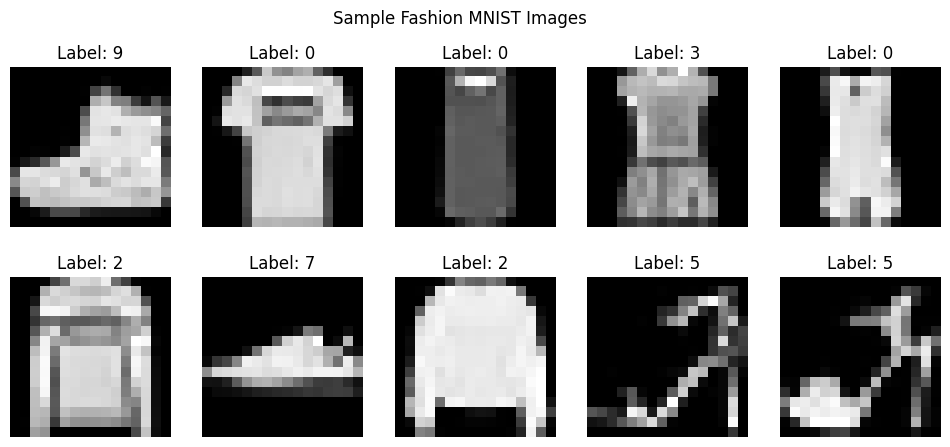

In [2]:
# data loading
x_train_viz, y_train_viz, _, _ = load_and_preprocess_fashion_mnist(
    resize_val=RESIZE_VAL,
    subset_size=SUBSET_SIZE_HYBRID, 
    flatten=False, 
    one_hot=False
)

# visualize images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_viz[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train_viz[i]}")
    plt.axis('off')
plt.suptitle("Sample Fashion MNIST Images")
plt.show()

## Global Search: Building with Blocks

We first define a `search_space` in a YAML file. This file provides SNAC-pack with the "Lego bricks" it can use to build and test new architectures. We'll allow it to choose between `Conv`, `MLP`, and `ConvAttn` blocks.


In [3]:

# yaml config
search_space_yaml = """
channel_space: [4, 8, 16]
mlp_width_space: [5, 16, 32, 64]
kernel_space: [1, 3, 5]
act_space: ["ReLU", "GELU", "LeakyRelu"]
norm_space: [null, "batch"]
block_types: ["Conv", "MLP", "None"]
num_blocks: 5
initial_img_size: 16
output_dim: 10
output_activation: "softmax"
"""

with open(SEARCH_SPACE_PATH, 'w') as f:
    f.write(search_space_yaml)
print(f"Created search space configuration file: {SEARCH_SPACE_PATH}")

# objectives (4 objectives: accuracy up, bops/resource/latency down)
OBJECTIVE_NAMES_HYBRID = ['performance_metric', 'bops', 'avg_resource', 'clock_cycles']
MAXIMIZE_FLAGS_HYBRID = [True, False, False, False]

# run the search
print("\n" + "="*50)
print("Running Part 2: Hybrid Architecture Global Search...")
print("This will take several minutes...")
print("="*50)

searcher_hybrid = GlobalSearchTF(search_space_path=SEARCH_SPACE_PATH, results_dir=RESULTS_DIR_HYBRID)

study_hybrid = searcher_hybrid.run_search(
    model_type='block',
    n_trials=N_TRIALS_HYBRID,
    epochs=EPOCHS_HYBRID,
    dataset='fashion_mnist',
    subset_size=SUBSET_SIZE_HYBRID,
    resize_val=searcher_hybrid.search_space.get('initial_img_size', 11),
    objectives=OBJECTIVE_NAMES_HYBRID,
    maximize_flags=MAXIMIZE_FLAGS_HYBRID,
    use_hardware_metrics=True,
    one_hot=True,
    n_folds=N_FOLDS,
)
print("\nGlobal Search Complete!")

Created search space configuration file: hybrid_search_space.yaml

Running Part 2: Hybrid Architecture Global Search...
This will take several minutes...

Starting BLOCK Global Search on FASHION_MNIST



[I 2026-02-12 17:54:09,754] A new study created in memory with name: no-name-738317e3-8d74-44f9-bdf6-de89aeb96248


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000, 10), y_val shape: (10000, 10)


[I 2026-02-12 17:57:46,648] Trial 0 finished with values: [0.8577676216761271, 35717120.0, 1.1275, 1025293.19] and parameters: {'b0': 'None', 'b1': 'None', 'b2': 'Conv', 'b3': 'Conv', 'b4': 'MLP', 'b2_Conv_channels_0': 2, 'b2_Conv_channels_1': 2, 'b2_Conv_kernels_0': 5, 'b2_Conv_kernels_1': 5, 'b2_Conv_acts_0': 'GELU', 'b2_Conv_acts_1': 'LeakyRelu', 'b2_Conv_norms_0': 'batch', 'b2_Conv_norms_1': None, 'b3_Conv_channels_0': 1, 'b3_Conv_channels_1': 0, 'b3_Conv_kernels_0': 1, 'b3_Conv_kernels_1': 1, 'b3_Conv_acts_0': 'ReLU', 'b3_Conv_acts_1': 'GELU', 'b3_Conv_norms_0': 'batch', 'b3_Conv_norms_1': 'batch', 'b4_MLP_units': 3, 'b4_MLP_act': 'ReLU', 'b4_MLP_norm': None, 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 2, 'MLP_Head_acts_0': 'LeakyRelu', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'LeakyRelu', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': 'batch'}.


Trial 0: Folds=[0.8526, 0.8615, 0.8593], MeanAcc=0.8578, BOPs=35717120, AvgResource=1.13%, Cycles=1025293.19


...

Trial 17: Folds=[0.8119, 0.8142, 0.8234], MeanAcc=0.8165, BOPs=2850816, AvgResource=1.08%, Cycles=197.89


[I 2026-02-12 18:22:11,296] Trial 18 finished with values: [0.854698896408081, 19562496.0, 4.619999999999999, 54.01] and parameters: {'b0': 'MLP', 'b1': 'Conv', 'b2': 'Conv', 'b3': 'None', 'b4': 'Conv', 'b0_MLP_units': 3, 'b0_MLP_act': 'ReLU', 'b0_MLP_norm': None, 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'LeakyRelu', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'LeakyRelu', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': None}.


Trial 18: Folds=[0.8572, 0.8625, 0.8445], MeanAcc=0.8547, BOPs=19562496, AvgResource=4.62%, Cycles=54.01


[I 2026-02-12 18:22:29,972] Trial 19 finished with values: [0.8082650303840637, 3096576.0, 1.04, 243.41] and parameters: {'b0': 'MLP', 'b1': 'Conv', 'b2': 'None', 'b3': 'Conv', 'b4': 'Conv', 'b0_MLP_units': 0, 'b0_MLP_act': 'ReLU', 'b0_MLP_norm': None, 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 3, 'MLP_Head_acts_0': 'GELU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}.


Trial 19: Folds=[0.8174, 0.8008, 0.8066], MeanAcc=0.8083, BOPs=3096576, AvgResource=1.04%, Cycles=243.41

CSV results saved to ./results/tutorial2/block_search_results.csv

🏆 Best model architecture (Trial 13) saved for local search:
   - Source: ./results/tutorial2/trial_13_arch.yaml
   - Destination: ./results/tutorial2/best_model_for_local_search.yaml
   - Accuracy: 0.8617

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 0):
  Values: {'performance_metric': 0.8577676216761271, 'bops': 35717120.0, 'avg_resource': 1.1275, 'clock_cycles': 1025293.19}
  Params: {'b0': 'None', 'b1': 'None', 'b2': 'Conv', 'b3': 'Conv', 'b4': 'MLP', 'b2_Conv_channels_0': 2, 'b2_Conv_channels_1': 2, 'b2_Conv_kernels_0': 5, 'b2_Conv_kernels_1': 5, 'b2_Conv_acts_0': 'GELU', 'b2_Conv_acts_1': 'LeakyRelu', 'b2_Conv_norms_0': 'batch', 'b2_Conv_norms_1': None, 'b3_Conv_channels_0': 1, 'b3_Conv_channels_1': 0, 'b3_Conv_kernels_0': 1, 'b3_Conv_kernels_1': 1, 'b3_Conv_acts_0': 'ReLU', 'b3_Conv_acts_1': 'GELU', 'b3_Conv_n

## Analyzing the Global Search Results

The search has finished exploring different architectural combinations. Let's see what it found!

--- Best Discovered Architecture (by Accuracy) ---
Trial Number: 13
Accuracy: 0.8617
BOPs: 2.16e+07
Avg Resource: 4.84%
Clock Cycles: 56

Architecture components:
- Type: Flatten, Name: initial_flatten
- Type: MLP, Name: mlp_block_4
- Type: MLP, Name: classifier_head

--- Visualizing Pairwise 2D Pareto Fronts ---
2D Pareto fronts plot saved to ./results/tutorial2/pareto_fronts_2d.png


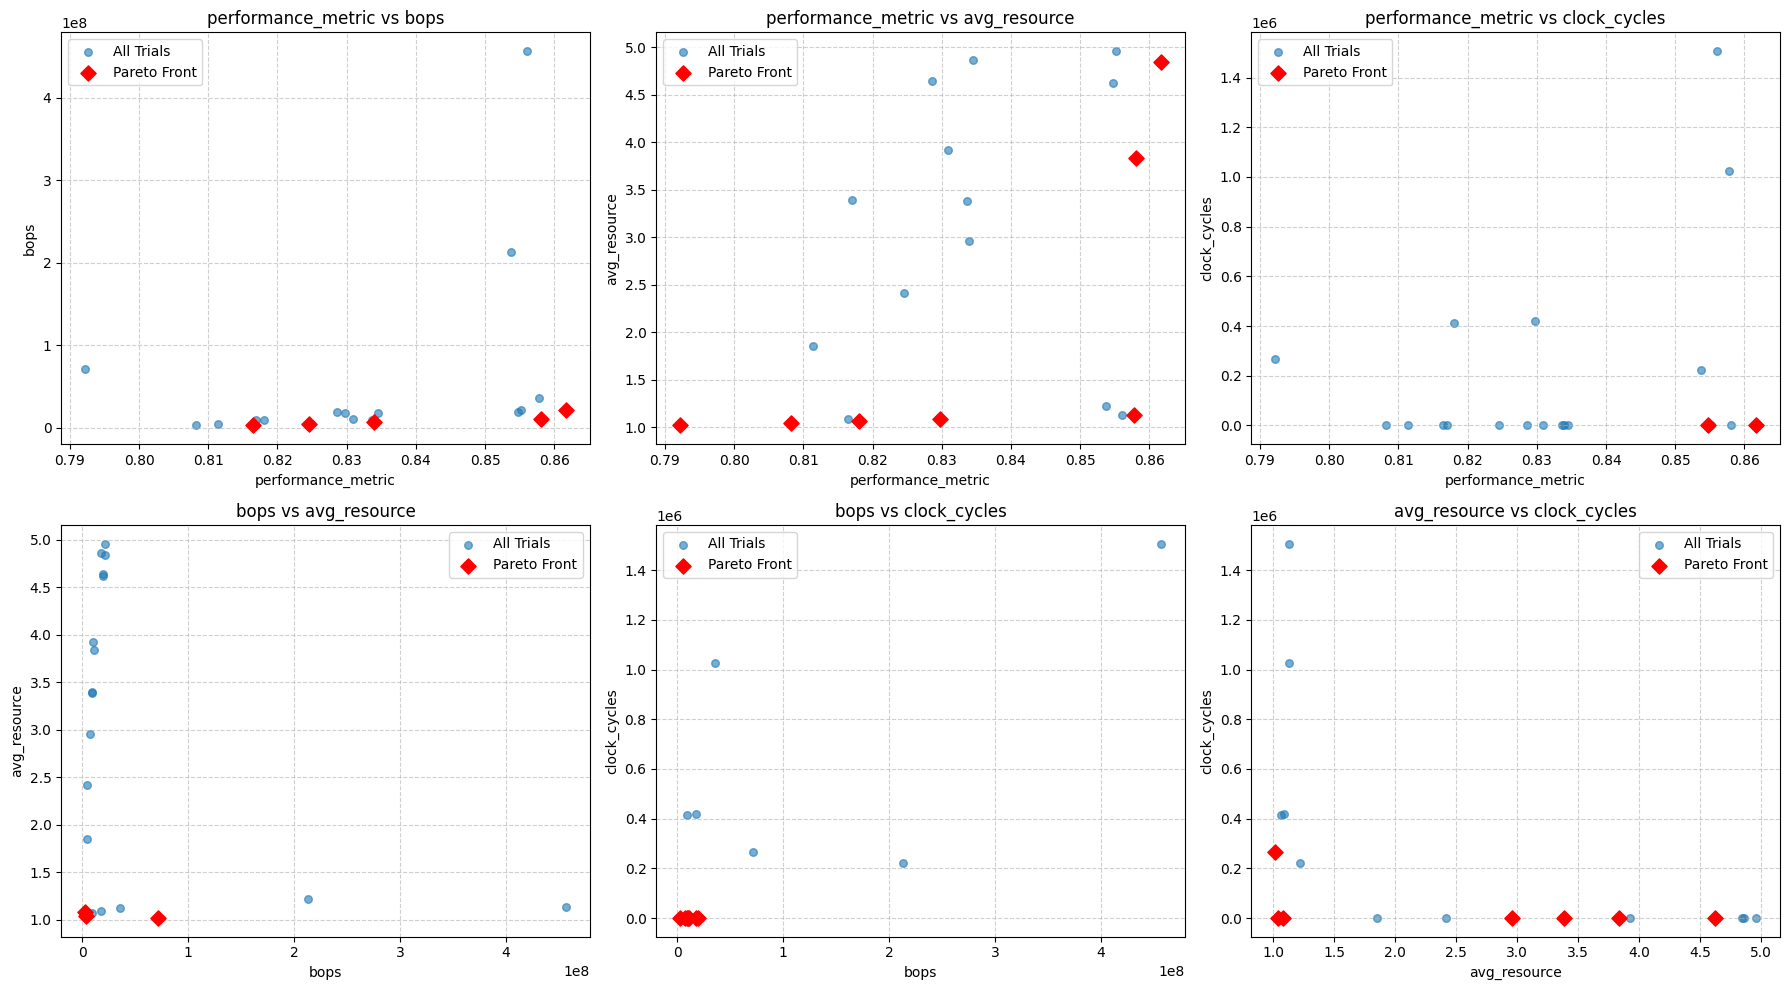


--- Generating 3D Pareto Front Heatmap ---
3D Pareto front plot saved to ./results/tutorial2/pareto_front_3d.html



Plots saved to: ./results/tutorial2


In [4]:

results_df_hybrid = pd.DataFrame(searcher_hybrid.results)

if not results_df_hybrid.empty:
    # Inspect best architecture
    print("--- Best Discovered Architecture (by Accuracy) ---")
    best_trial_row = results_df_hybrid.loc[results_df_hybrid['performance_metric'].idxmax()]
    print(f"Trial Number: {best_trial_row['trial']}")
    print(f"Accuracy: {best_trial_row['performance_metric']:.4f}")
    print(f"BOPs: {best_trial_row['bops']:.2e}")
    print(f"Avg Resource: {best_trial_row['avg_resource']:.2f}%")
    print(f"Clock Cycles: {best_trial_row['clock_cycles']:.0f}")

    with open(best_trial_row['yaml_path'], 'r') as f:
        best_arch_yaml = yaml.safe_load(f)

    print("\nArchitecture components:")
    for component in best_arch_yaml['architecture']['components']:
        print(f"- Type: {component['block_type']}, Name: {component['name']}")

    # Build objective info list for plotting
    OBJECTIVE_INFO_HYBRID = list(zip(OBJECTIVE_NAMES_HYBRID, MAXIMIZE_FLAGS_HYBRID))

    # Pairwise 2D Pareto fronts (6 combinations)
    print("\n--- Visualizing Pairwise 2D Pareto Fronts ---")
    plot_pareto_fronts(results_df_hybrid, OBJECTIVE_INFO_HYBRID, save_dir=searcher_hybrid.results_dir)

    # Interactive 3D Pareto front with clock_cycles as heatmap color
    print("\n--- Generating 3D Pareto Front Heatmap ---")
    plot_3d_pareto_front_heatmap(results_df_hybrid, OBJECTIVE_INFO_HYBRID, save_dir=searcher_hybrid.results_dir)

    print(f"\nPlots saved to: {searcher_hybrid.results_dir}")
else:
    print("Hybrid search did not yield any results to analyze.")



## Local Search: Model Compression

Just like before, the global search saved the best model. We will now apply compression to refine the chosen model.


In [6]:
LOCAL_SEARCH_RESULTS_DIR = os.path.join(RESULTS_DIR_HYBRID, "t2_local_results")
LOCAL_SEARCH_CONFIG_PATH = os.path.join(RESULTS_DIR_HYBRID, "t2_local_config.yaml")
ARCHITECTURE_YAML_PATH = os.path.join(RESULTS_DIR_HYBRID, "best_model_for_local_search.yaml")

local_search_settings = {
    "pruning_settings": {
        "iterations": 10,
        "epochs_per_iteration": 5,
        "pruning_rate": 0.7,
    },
    "qat_settings": {
        "epochs": 5,
        "precision_pairs": [
            {"total_bits": 16, "int_bits": 6},
            {"total_bits": 8, "int_bits": 3},
            {"total_bits": 6, "int_bits": 2},
            {"total_bits": 4, "int_bits": 1},
        ],
    },
}

with open(LOCAL_SEARCH_CONFIG_PATH, "w") as f:
    yaml.dump(local_search_settings, f)

# Load dataset (one-hot = True for classification)
x_train, y_train, x_val, y_val = load_and_preprocess_fashion_mnist(
    resize_val=RESIZE_VAL,
    subset_size=SUBSET_SIZE_HYBRID,
    flatten=False,
    one_hot=True,
)

if not os.path.exists(ARCHITECTURE_YAML_PATH):
    raise FileNotFoundError(
        f"Could not find best architecture YAML: {ARCHITECTURE_YAML_PATH}. "
        "Run global search first."
    )

combined_results_df = combined_local_search_entrypoint(
    architecture_yaml_path=ARCHITECTURE_YAML_PATH,
    local_search_config_path=LOCAL_SEARCH_CONFIG_PATH,
    dataset=(x_train, y_train, x_val, y_val),
    results_dir=LOCAL_SEARCH_RESULTS_DIR,
)


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000, 10), y_val shape: (10000, 10)

 STARTING COMBINED QAT+PRUNING LOCAL SEARCH 
Baseline FP32 BOPs: 2.30e+07

==================== Precision: <16,6> ====================
  QAT warmup (5 epochs)... accuracy=0.7459, eff_bops=5.75e+06
  Iter  1/10: acc=0.8019  sparsity=0.2976  eff_bops=4.04e+06 *
  Iter  2/10: acc=0.7771  sparsity=0.5059  eff_bops=2.84e+06
  Iter  3/10: acc=0.8170  sparsity=0.6518  eff_bops=2.00e+06 *
  Iter  4/10: acc=0.8103  sparsity=0.7538  eff_bops=1.42e+06
  Iter  5/10: acc=0.8198  sparsity=0.8253  eff_bops=1.01e+06 *
  Iter  6/10: acc=0.8155  sparsity=0.8753  eff_bops=7.17e+05
  Iter  7/10: acc=0.8097  sparsity=0.9103  eff_bops=5.16e+05
  Iter  8/10: acc=0.7928  sparsity=0.9348  eff_bops=3.75e+05
  Iter  9/10: acc=0.5729  sparsity=0.9519  eff_bops=2.76e+05
  Iter 10/10: acc=0.3818  sparsity=0.9640  eff_bops=2.07e+05
  Best <16,6>: a

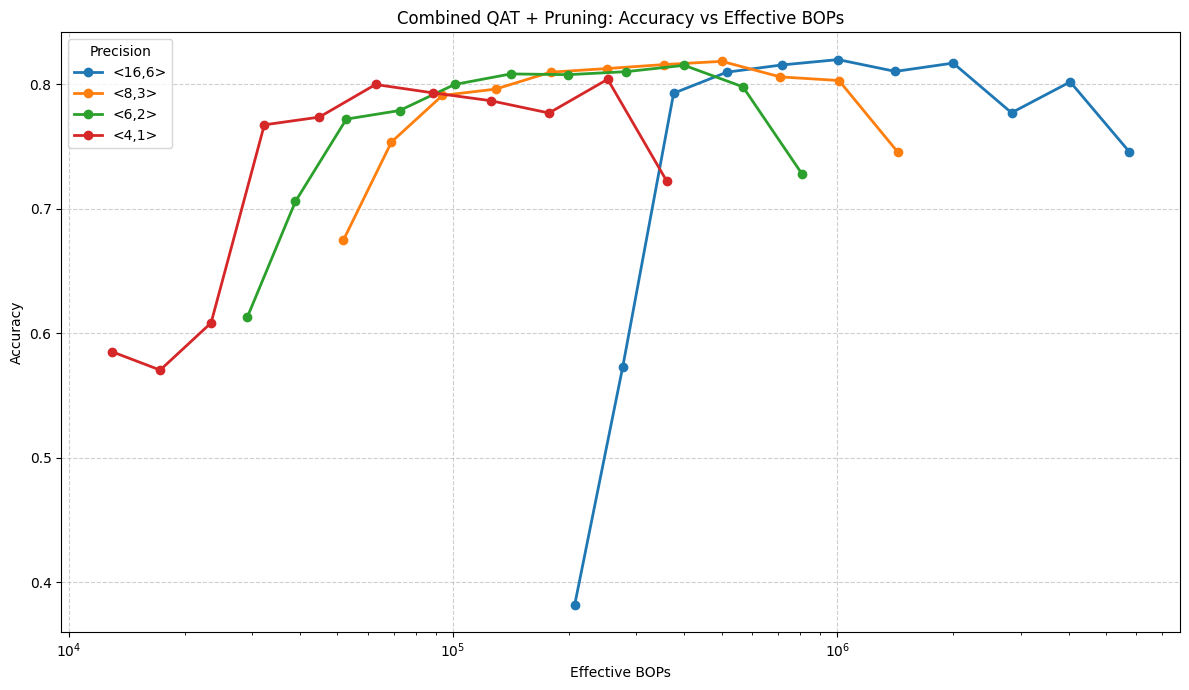

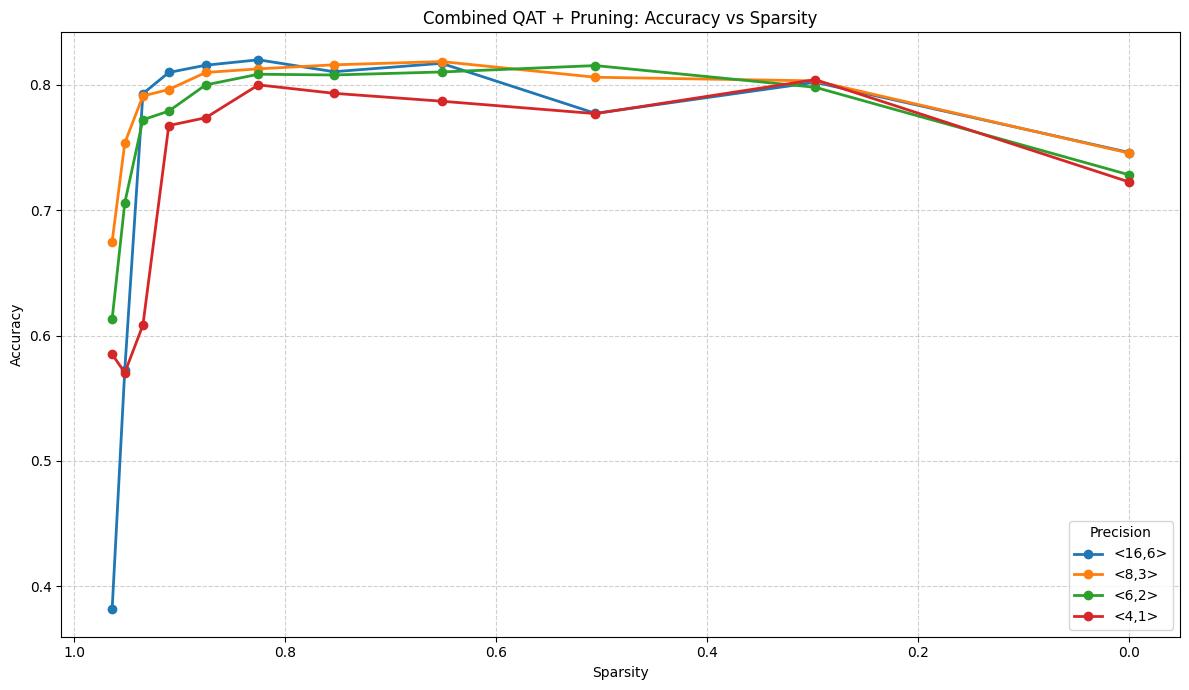

In [7]:
if isinstance(combined_results_df, pd.DataFrame) and not combined_results_df.empty:
    # Accuracy vs Effective BOPs (one curve per precision)
    plt.figure(figsize=(12, 7))
    for prec in combined_results_df["Precision"].unique():
        subset = combined_results_df[combined_results_df["Precision"] == prec]
        plt.plot(subset["EffectiveBOPs"], subset["Accuracy"], marker="o", linewidth=2, label=prec)
    plt.xlabel("Effective BOPs")
    plt.ylabel("Accuracy")
    plt.title("Combined QAT + Pruning: Accuracy vs Effective BOPs")
    plt.legend(title="Precision")
    plt.xscale("log")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Accuracy vs Sparsity (one curve per precision)
    plt.figure(figsize=(12, 7))
    for prec in combined_results_df["Precision"].unique():
        subset = combined_results_df[combined_results_df["Precision"] == prec]
        plt.plot(subset["Sparsity"], subset["Accuracy"], marker="o", linewidth=2, label=prec)
    plt.xlabel("Sparsity")
    plt.ylabel("Accuracy")
    plt.title("Combined QAT + Pruning: Accuracy vs Sparsity")
    plt.legend(title="Precision")
    plt.gca().invert_xaxis()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No combined local search results to plot.")
